<a href="https://colab.research.google.com/github/zidannugraharey/Capstone-Project/blob/main/AmazonSales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Kelompok 3**  
1.Zidan Nugraha Rey (2407112382) (Ketua)  
2.Nicholas Adi Putra T (2407111549)  
3.Muhammad Nabil Alfathan (2407126577)

Judul Project: **Analisis Data Komputasi dari Amazon Sales Dataset**  
Link Dataset: https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset

## Ikhtisar Proyek: Analisis Penjualan Amazon

Notebook ini didedikasikan untuk melakukan Analisis Data Eksplorasi (EDA) pada **Amazon Sales Dataset** yang diunduh dari Kaggle. Tujuan utama dari proyek ini adalah untuk memahami pola-pola dalam data penjualan, harga, diskon, rating produk, dan ulasan, serta mengidentifikasi hubungan antar variabel.

**Alur Kerja Notebook:**
1.  **Pengambilan dan Pemuatan Data**: Mengunduh dataset dari Kaggle dan memuatnya ke Pandas DataFrame.
2.  **Pembersihan dan Pra-pemrosesan Data**: Membersihkan dan mengonversi tipe data kolom-kolom kunci untuk analisis.
3.  **Analisis Data Eksplorasi (EDA)**: Menganalisis distribusi harga, diskon, rating, kategori produk, serta korelasi antar variabel.
4.  **Kesimpulan EDA**: Merangkum temuan-temuan utama dari analisis.

### Mengatur Kaggle API Key di Colab Secrets
Untuk mendownload dataset dari Kaggle, Anda perlu mengautentikasi menggunakan Kaggle API key Anda. Anda dapat memperoleh API key dari akun Kaggle Anda (Profil -> Account -> Create New API Token).

Setelah mendapatkan file `kaggle.json` (yang berisi username dan key Anda), Anda harus menyimpannya sebagai Colab Secret. Klik ikon 'Kunci' di panel kiri Colab, lalu tambahkan secret baru dengan nama `KAGGLE_USERNAME` (untuk username Anda) dan `KAGGLE_KEY` (untuk API key Anda).

In [12]:
# Instal library Kaggle
!pip install kaggle

In [18]:
import os
from google.colab import userdata

# Buat direktori .kaggle jika belum ada
!mkdir -p ~/.kaggle

# Ambil kredensial dari Colab Secrets
kaggle_username = userdata.get('KAGGLE_USERNAME')
kaggle_key = userdata.get('KAGGLE_KEY')

# Tulis kredensial ke file kaggle.json
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(f'{{"username":"{kaggle_username}","key":"{kaggle_key}"}}')

# Atur izin file
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key telah berhasil dikonfigurasi.")

Kaggle API key telah berhasil dikonfigurasi.


In [14]:
# Download dataset dari Kaggle
# Nama dataset: karkavelrajaj/amazon-sales-dataset
!kaggle datasets download -d karkavelrajaj/amazon-sales-dataset

print("Dataset berhasil didownload.")

Dataset URL: https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset
License(s): CC-BY-NC-SA-4.0
amazon-sales-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset berhasil didownload.


In [15]:
# Unzip file dataset
import zipfile

zip_file_path = 'amazon-sales-dataset.zip'
output_dir = '.' # Ekstrak ke direktori saat ini

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f"File '{zip_file_path}' berhasil diekstrak ke '{output_dir}'.")

File 'amazon-sales-dataset.zip' berhasil diekstrak ke '.'.


## Tahap 1: Pengambilan dan Pemuatan Data

Bagian ini mencakup instalasi library Kaggle, konfigurasi API key menggunakan Colab Secrets untuk otentikasi, pengunduhan dataset `amazon-sales-dataset.zip` dari Kaggle, ekstraksi file CSV, dan pemuatan data ke dalam Pandas DataFrame untuk analisis lebih lanjut.

In [16]:
import pandas as pd

# Muat file CSV ke dalam DataFrame
file_csv = 'amazon.csv'
df = pd.read_csv(file_csv)

# Tampilkan 5 baris pertama DataFrame
print(f"DataFrame '{file_csv}' berhasil dimuat. Berikut 5 baris pertamanya:")
display(df.head())

DataFrame 'amazon.csv' berhasil dimuat. Berikut 5 baris pertamanya:


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [19]:
print("Informasi umum DataFrame:")
df.info()

print("\nStatistik deskriptif DataFrame:")
display(df.describe(include='all'))

Informasi umum DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B083342NKJ,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Borosil-Jumbo-1000-Watt-...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


## Tahap 2: Pembersihan dan Pra-pemrosesan Data

Pada tahap ini, data mentah dari dataset akan dibersihkan dan dikonversi ke tipe data yang sesuai. Fokus utama adalah pada kolom-kolom numerik seperti `discounted_price`, `actual_price`, `discount_percentage`, `rating`, dan `rating_count`. Nilai non-numerik akan ditangani, simbol mata uang atau persentase akan dihapus, dan tipe data akan dikonversi menjadi float untuk memungkinkan perhitungan matematis dan analisis yang akurat.

In [22]:
# Membersihkan dan mengonversi kolom 'discounted_price' dan 'actual_price'
# Menghapus simbol mata uang dan koma, lalu mengonversi ke float
df['discounted_price'] = df['discounted_price'].astype(str).str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['actual_price'] = df['actual_price'].astype(str).str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)

print("Kolom 'discounted_price' dan 'actual_price' berhasil dibersihkan dan dikonversi ke tipe data float.")
print("Memverifikasi tipe data baru:")
df[['discounted_price', 'actual_price']].info()

Kolom 'discounted_price' dan 'actual_price' berhasil dibersihkan dan dikonversi ke tipe data float.
Memverifikasi tipe data baru:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   discounted_price  1465 non-null   float64
 1   actual_price      1465 non-null   float64
dtypes: float64(2)
memory usage: 23.0 KB


### Pembersihan dan Konversi Kolom `discount_percentage`
Kolom `discount_percentage` saat ini bertipe `object` dan mengandung simbol `%`. Kita akan menghapus simbol tersebut dan mengonversinya ke tipe `float`, lalu membaginya dengan 100 agar menjadi nilai desimal yang representatif untuk persentase.

In [23]:
# Membersihkan dan mengonversi kolom 'discount_percentage'
# Menghapus simbol '%' dan mengonversi ke float, lalu dibagi 100
df['discount_percentage'] = df['discount_percentage'].astype(str).str.replace('%', '', regex=False).astype(float) / 100

print("Kolom 'discount_percentage' berhasil dibersihkan dan dikonversi ke tipe data float (dalam desimal).")
print("Memverifikasi tipe data baru:")
display(df[['discount_percentage']].info())

Kolom 'discount_percentage' berhasil dibersihkan dan dikonversi ke tipe data float (dalam desimal).
Memverifikasi tipe data baru:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 1 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   discount_percentage  1465 non-null   float64
dtypes: float64(1)
memory usage: 11.6 KB


None

### Pembersihan dan Konversi Kolom `rating`
Kolom `rating` juga bertipe `object` dan mungkin berisi nilai non-numerik seperti 'No rating available' atau 'stars'. Kita perlu mengganti nilai-nilai tersebut dengan `NaN` (Not a Number) dan kemudian mengonversi kolom ini ke tipe `float`.

In [24]:
# Membersihkan dan mengonversi kolom 'rating'
# Mengganti nilai non-numerik dengan NaN dan mengonversi ke float
df['rating'] = df['rating'].replace('No rating available', pd.NA)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce') # 'coerce' akan mengubah nilai yang tidak bisa dikonversi menjadi NaN

print("Kolom 'rating' berhasil dibersihkan dan dikonversi ke tipe data float.")
print("Memverifikasi tipe data baru dan jumlah nilai yang hilang:")
display(df[['rating']].info())

Kolom 'rating' berhasil dibersihkan dan dikonversi ke tipe data float.
Memverifikasi tipe data baru dan jumlah nilai yang hilang:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   rating  1464 non-null   float64
dtypes: float64(1)
memory usage: 11.6 KB


None

### Pembersihan dan Konversi Kolom `rating_count`
Kolom `rating_count` saat ini bertipe `object`, memiliki nilai yang hilang, dan kemungkinan mengandung koma sebagai pemisah ribuan. Kita akan membersihkan koma, mengganti nilai non-numerik (termasuk nilai yang hilang secara eksplisit seperti 'No ratings yet' atau nilai `pd.NA` yang mungkin muncul setelah pembersihan rating) dengan `NaN`, dan kemudian mengonversinya ke tipe `float` atau `int`.

In [25]:
# Membersihkan dan mengonversi kolom 'rating_count'
# Menghapus koma, mengganti nilai non-numerik dengan NaN, dan mengonversi ke float
df['rating_count'] = df['rating_count'].astype(str).str.replace(',', '', regex=False) # Hapus koma
df['rating_count'] = df['rating_count'].replace('No ratings yet', pd.NA) # Ganti string 'No ratings yet' dengan NaN jika ada
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce') # 'coerce' akan mengubah nilai yang tidak bisa dikonversi menjadi NaN

print("Kolom 'rating_count' berhasil dibersihkan dan dikonversi ke tipe data float.")
print("Memverifikasi tipe data baru dan jumlah nilai yang hilang:")
display(df[['rating_count']].info())

Kolom 'rating_count' berhasil dibersihkan dan dikonversi ke tipe data float.
Memverifikasi tipe data baru dan jumlah nilai yang hilang:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rating_count  1463 non-null   float64
dtypes: float64(1)
memory usage: 11.6 KB


None

### Ringkasan Tipe Data Setelah Pembersihan
Sekarang mari kita lihat kembali informasi umum DataFrame untuk memastikan semua kolom target sudah memiliki tipe data yang benar.

In [26]:
print("Informasi umum DataFrame setelah pembersihan kolom-kolom kunci:")
df.info()

print("\nStatistik deskriptif untuk kolom-kolom yang sudah dibersihkan:")
display(df[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']].describe())

Informasi umum DataFrame setelah pembersihan kolom-kolom kunci:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   float64
 6   rating               1464 non-null   float64
 7   rating_count         1463 non-null   float64
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             146

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1465.000000,1465.000000,1465.000000,1464.000000,1463.000000
mean,3125.310874,5444.990635,0.476915,4.096585,18295.541353
std,6944.304394,10874.826864,0.216359,0.291674,42753.864952
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,325.000000,800.000000,0.320000,4.000000,1186.000000
50%,799.000000,1650.000000,0.500000,4.100000,5179.000000
75%,1999.000000,4295.000000,0.630000,4.300000,17336.500000
max,77990.000000,139900.000000,0.940000,5.000000,426973.000000


## Tahap 3: Analisis Data Eksplorasi (EDA)

Setelah data dibersihkan dan diproses, tahap ini berfokus pada eksplorasi data untuk mengungkap pola, tren, dan wawasan. Kami akan menganalisis distribusi harga dan diskon, performa produk berdasarkan kategori dan rating, serta hubungan korelasi antar variabel numerik melalui berbagai visualisasi dan statistik deskriptif.

## Analisis Harga dan Diskon

Kita akan memulai Analisis Data Eksplorasi (EDA) dengan memeriksa distribusi `actual_price`, `discounted_price`, dan `discount_percentage`. Ini akan membantu kita memahami pola harga dan strategi diskon dalam dataset.

Visualisasi yang Digunakan:
*   **Histogram**: Digunakan untuk menampilkan distribusi `actual_price` dan `discounted_price`.

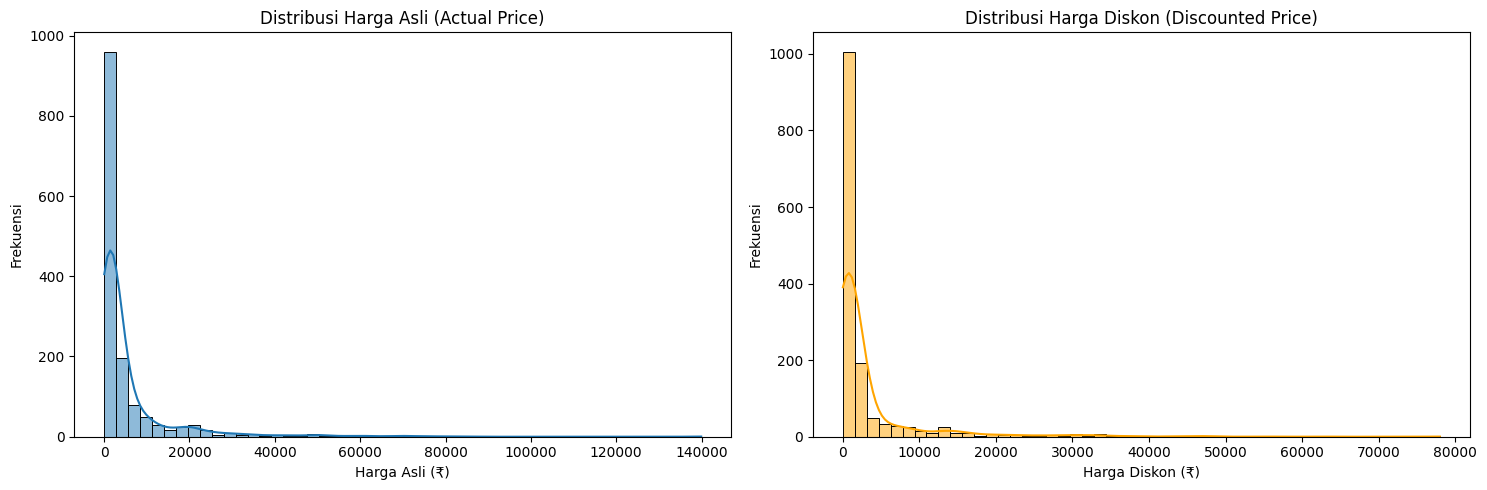

Statistik deskriptif untuk harga:


,actual_price,discounted_price
count,1465.000000,1465.000000
mean,5444.990635,3125.310874
std,10874.826864,6944.304394
min,39.000000,39.000000
25%,800.000000,325.000000
50%,1650.000000,799.000000
75%,4295.000000,1999.000000
max,139900.000000,77990.000000


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# Histogram untuk actual_price
plt.subplot(1, 2, 1)
sns.histplot(df['actual_price'], bins=50, kde=True)
plt.title('Distribusi Harga Asli (Actual Price)')
plt.xlabel('Harga Asli (₹)')
plt.ylabel('Frekuensi')

# Histogram untuk discounted_price
plt.subplot(1, 2, 2)
sns.histplot(df['discounted_price'], bins=50, kde=True, color='orange')
plt.title('Distribusi Harga Diskon (Discounted Price)')
plt.xlabel('Harga Diskon (₹)')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

print("Statistik deskriptif untuk harga:")
display(df[['actual_price', 'discounted_price']].describe())

### Distribusi Persentase Diskon

Selanjutnya, mari kita lihat bagaimana persentase diskon didistribusikan.

Visualisasi yang Digunakan:
*   **Histogram**: Digunakan untuk menampilkan distribusi `discount_percentage`.

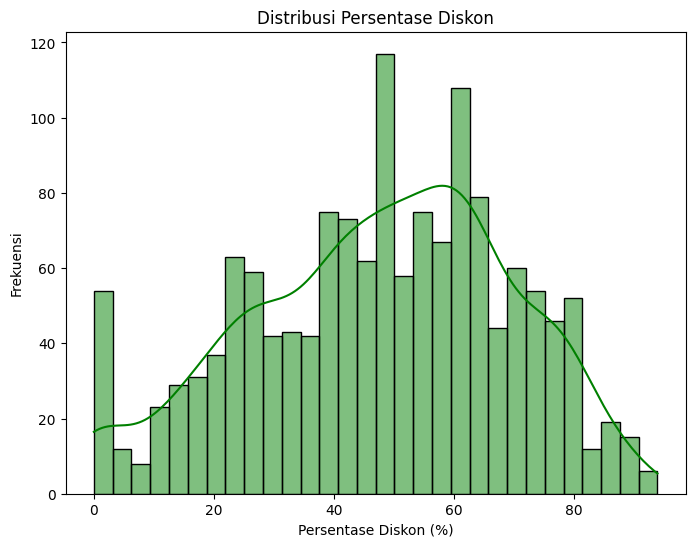

Statistik deskriptif untuk persentase diskon:


,discount_percentage
count,1465.000000
mean,0.476915
std,0.216359
min,0.000000
25%,0.320000
50%,0.500000
75%,0.630000
max,0.940000


In [28]:
plt.figure(figsize=(8, 6))
sns.histplot(df['discount_percentage'] * 100, bins=30, kde=True, color='green') # Dikalikan 100 agar dalam persentase
plt.title('Distribusi Persentase Diskon')
plt.xlabel('Persentase Diskon (%)')
plt.ylabel('Frekuensi')
plt.show()

print("Statistik deskriptif untuk persentase diskon:")
display(df['discount_percentage'].describe())

## Analisis Performa Produk dan Kategori

Visualisasi yang Digunakan:
*   **Bar Plot**: Digunakan untuk menampilkan `Top 15 Kategori Produk Berdasarkan Jumlah Item`.

### 1. Distribusi Kategori Produk

/tmp/ipykernel_1315/702554771.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Category', data=category_counts.head(15), palette='viridis')


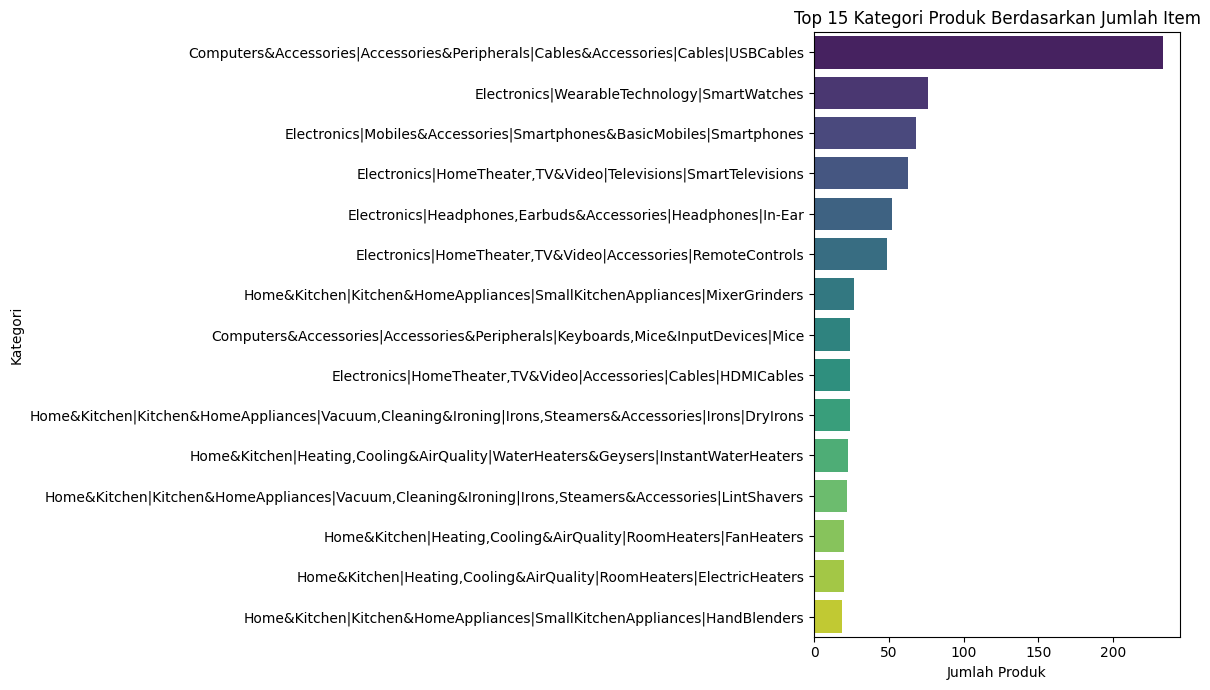

Jumlah produk per kategori:


,Category,Count
0,Computers&Accessories|Accessories&Peripherals|...,233
1,Electronics|WearableTechnology|SmartWatches,76
2,Electronics|Mobiles&Accessories|Smartphones&Ba...,68
3,"Electronics|HomeTheater,TV&Video|Televisions|S...",63
4,"Electronics|Headphones,Earbuds&Accessories|Hea...",52
5,"Electronics|HomeTheater,TV&Video|Accessories|R...",49
6,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,27
7,Computers&Accessories|Accessories&Peripherals|...,24
8,"Electronics|HomeTheater,TV&Video|Accessories|C...",24
9,"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...",24


In [34]:
# Menghitung jumlah produk per kategori
category_counts = df['category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']

plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='Category', data=category_counts.head(15), palette='viridis')
plt.title('Top 15 Kategori Produk Berdasarkan Jumlah Item')
plt.xlabel('Jumlah Produk')
plt.ylabel('Kategori')
plt.tight_layout()
plt.show()

print("Jumlah produk per kategori:")
display(category_counts.head(15))

### 2. Distribusi Rating dan Jumlah Ulasan

Visualisasi yang Digunakan:
*   **Histogram**: Digunakan untuk menampilkan distribusi `rating` dan `rating_count`. Untuk `rating_count`, skala logaritmik digunakan karena distribusinya sangat miring.

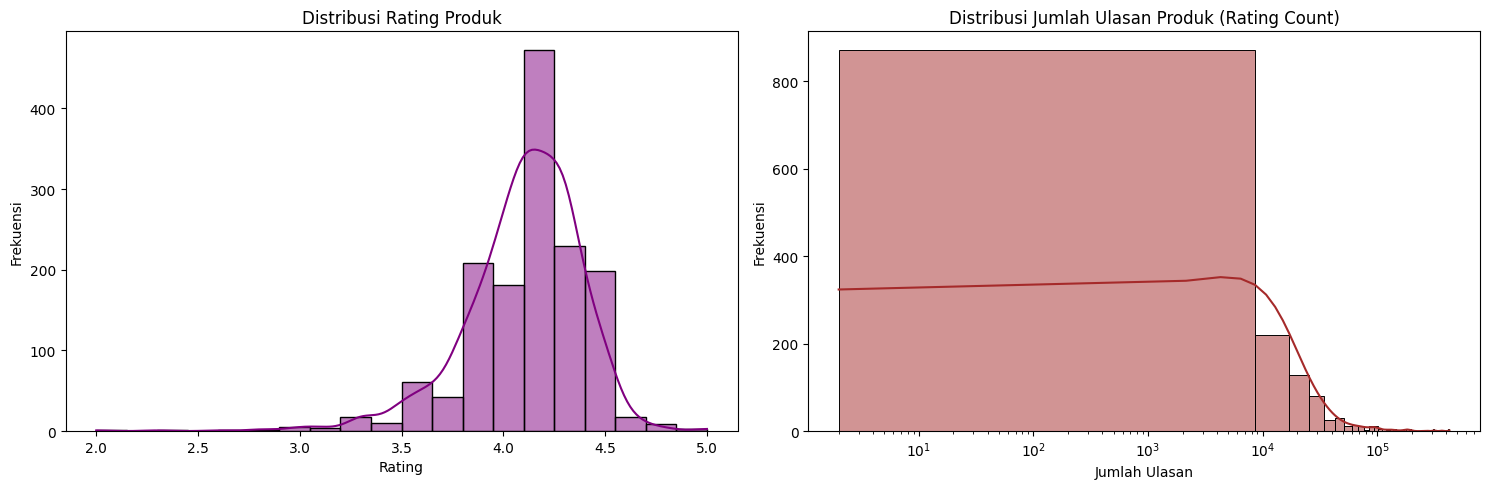

Statistik deskriptif untuk Rating dan Rating Count:


,rating,rating_count
count,1464.000000,1463.000000
mean,4.096585,18295.541353
std,0.291674,42753.864952
min,2.000000,2.000000
25%,4.000000,1186.000000
50%,4.100000,5179.000000
75%,4.300000,17336.500000
max,5.000000,426973.000000


In [35]:
plt.figure(figsize=(15, 5))

# Histogram untuk Rating
plt.subplot(1, 2, 1)
sns.histplot(df['rating'].dropna(), bins=20, kde=True, color='purple')
plt.title('Distribusi Rating Produk')
plt.xlabel('Rating')
plt.ylabel('Frekuensi')

# Histogram untuk Rating Count
plt.subplot(1, 2, 2)
sns.histplot(df['rating_count'].dropna(), bins=50, kde=True, color='brown')
plt.title('Distribusi Jumlah Ulasan Produk (Rating Count)')
plt.xlabel('Jumlah Ulasan')
plt.ylabel('Frekuensi')
plt.xscale('log') # Menggunakan skala logaritmik karena data sangat miring
plt.tight_layout()
plt.show()

print("Statistik deskriptif untuk Rating dan Rating Count:")
display(df[['rating', 'rating_count']].describe())

### 3. Performa Rata-rata per Kategori

Visualisasi yang Digunakan:
*   **Bar Plot**: Digunakan untuk menampilkan `Top 10 Kategori Berdasarkan Rating Rata-rata`.

Performa rata-rata (Rating, Rating Count, Harga, Diskon) per Kategori:


,category,rating,rating_count,actual_price,discounted_price,discount_percentage
0,Computers&Accessories|Tablets,4.6,2886.0,37999.0,26999.0,0.29
1,Computers&Accessories|NetworkingDevices|Networ...,4.5,22420.0,1999.0,1199.0,0.40
2,Electronics|Cameras&Photography|Accessories|Film,4.5,4875.0,549.0,549.0,0.00
3,Computers&Accessories|Components|Memory,4.5,26194.0,3500.0,1792.0,0.49
4,Electronics|HomeAudio|MediaStreamingDevices|St...,4.5,224.0,4699.0,4699.0,0.00
5,OfficeProducts|OfficeElectronics|Calculators|B...,4.5,8610.0,440.0,440.0,0.00
6,HomeImprovement|Electrical|CordManagement,4.5,5985.0,599.0,249.0,0.58
7,"Home&Kitchen|Kitchen&HomeAppliances|Coffee,Tea...",4.5,1065.0,1500.0,1099.0,0.27
8,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,4.5,2280.0,747.0,688.0,0.08
9,Electronics|PowerAccessories|SurgeProtectors,4.5,20668.0,1499.0,1289.0,0.14


/tmp/ipykernel_1315/1475069118.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rating', y='category', data=category_performance.head(10), palette='plasma')


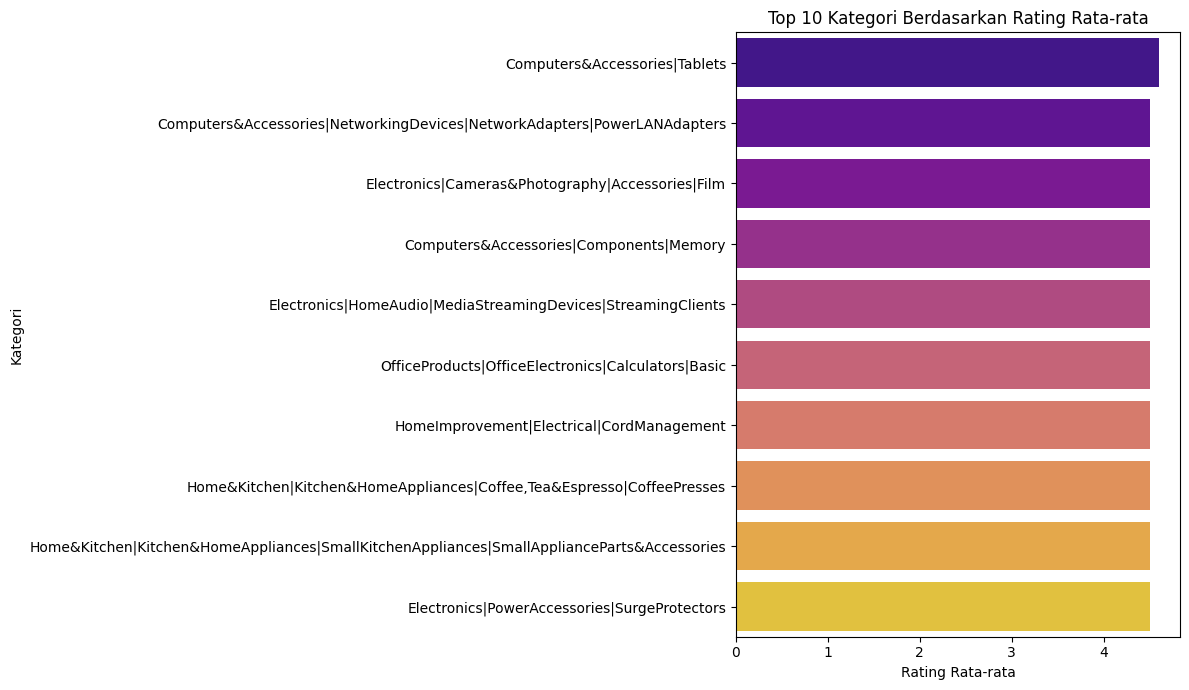

In [36]:
category_performance = df.groupby('category')[['rating', 'rating_count', 'actual_price', 'discounted_price', 'discount_percentage']].mean().sort_values(by='rating', ascending=False).reset_index()

print("Performa rata-rata (Rating, Rating Count, Harga, Diskon) per Kategori:")
display(category_performance.head(10))

# Visualisasi Rating Rata-rata per Kategori (Top 10)
plt.figure(figsize=(12, 7))
sns.barplot(x='rating', y='category', data=category_performance.head(10), palette='plasma')
plt.title('Top 10 Kategori Berdasarkan Rating Rata-rata')
plt.xlabel('Rating Rata-rata')
plt.ylabel('Kategori')
plt.tight_layout()
plt.show()

### 4. Analisis Korelasi Antar Variabel Numerik

Visualisasi yang Digunakan:
*   **Heatmap**: Digunakan untuk memvisualisasikan `Matriks Korelasi Antar Variabel Numerik`.

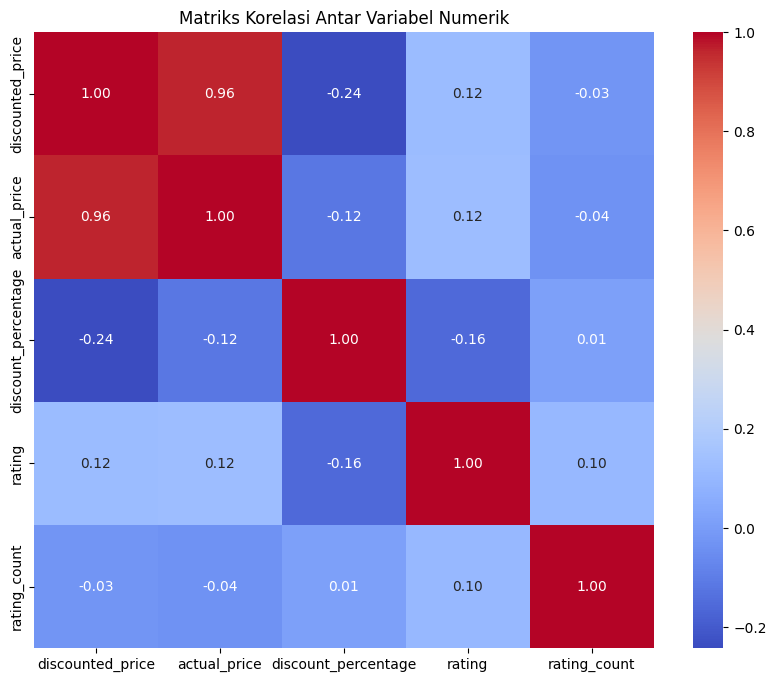

Matriks Korelasi:


,discounted_price,actual_price,discount_percentage,rating,rating_count
discounted_price,1.000000,0.961915,-0.242412,0.120337,-0.027261
actual_price,0.961915,1.000000,-0.118098,0.121642,-0.036137
discount_percentage,-0.242412,-0.118098,1.000000,-0.155375,0.011691
rating,0.120337,0.121642,-0.155375,1.000000,0.102235
rating_count,-0.027261,-0.036137,0.011691,0.102235,1.000000


In [37]:
numerical_cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Antar Variabel Numerik')
plt.show()

print("Matriks Korelasi:")
display(correlation_matrix)

### 5. Visualisasi Hubungan Spesifik

Visualisasi yang Digunakan:
*   **Scatter Plot**: Digunakan untuk menunjukkan hubungan antara `Diskon (%) vs Rating Produk` dan `Diskon (%) vs Jumlah Ulasan (Rating Count)`.

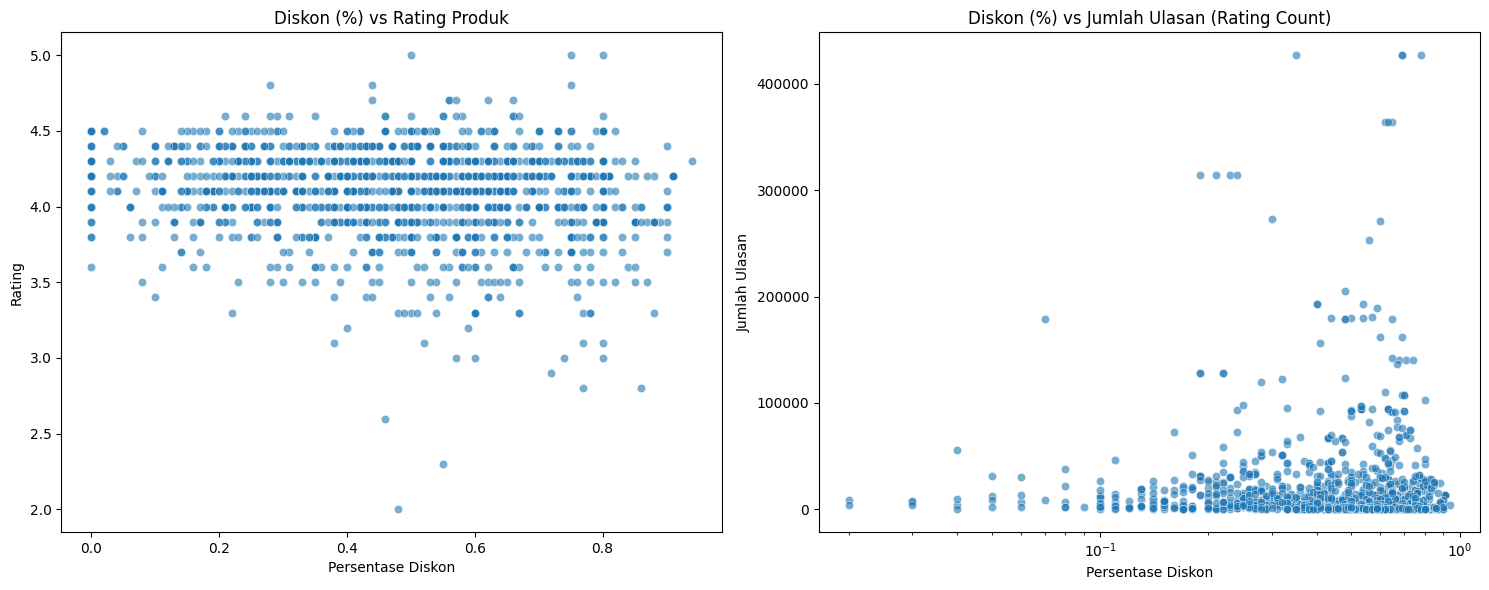

In [39]:
plt.figure(figsize=(15, 6))

# Hubungan antara Discount Percentage dan Rating
plt.subplot(1, 2, 1)
sns.scatterplot(x='discount_percentage', y='rating', data=df, alpha=0.6)
plt.title('Diskon (%) vs Rating Produk')
plt.xlabel('Persentase Diskon')
plt.ylabel('Rating')

# Hubungan antara Discount Percentage dan Rating Count
plt.subplot(1, 2, 2)
sns.scatterplot(x='discount_percentage', y='rating_count', data=df, alpha=0.6)
plt.title('Diskon (%) vs Jumlah Ulasan (Rating Count)')
plt.xlabel('Persentase Diskon')
plt.ylabel('Jumlah Ulasan')
plt.xscale('log') # Rating Count mungkin perlu skala logaritmik
plt.tight_layout()
plt.show()

## Ringkasan Kesimpulan EDA

Dari analisis data eksplorasi yang telah dilakukan, beberapa temuan kunci dapat disimpulkan:

1.  **Pembersihan Data**: Kolom-kolom kunci seperti `discounted_price`, `actual_price`, `discount_percentage`, `rating`, dan `rating_count` berhasil dibersihkan dan dikonversi ke format numerik yang tepat, siap untuk analisis.

2.  **Analisis Harga dan Diskon**:
    *   Distribusi harga (aktual dan diskon) menunjukkan kemiringan ke kanan, mengindikasikan bahwa mayoritas produk memiliki harga yang relatif terjangkau, dengan beberapa produk berharga tinggi.
    *   Rata-rata persentase diskon yang signifikan (sekitar 47.69%) menunjukkan strategi diskon yang agresif dalam dataset ini.

3.  **Performa Produk dan Kategori**:
    *   Kategori produk seperti `Computers&Accessories` dan `Electronics` mendominasi dataset dalam hal jumlah item.
    *   Sebagian besar produk memiliki rating yang tinggi (rata-rata sekitar 4.1 dari 5), menunjukkan kepuasan pelanggan yang baik secara umum. Distribusi jumlah ulasan sangat miring, dengan sedikit produk yang memiliki ulasan sangat banyak.
    *   Beberapa kategori menunjukkan rating rata-rata yang sangat tinggi, meskipun dengan jumlah ulasan yang bervariasi.

4.  **Korelasi Antar Variabel Numerik**:
    *   Terdapat korelasi positif yang sangat kuat antara `discounted_price` dan `actual_price`.
    *   Korelasi antara variabel harga/diskon dengan `rating` dan `rating_count` cenderung lemah. Ini mengindikasikan bahwa harga atau besaran diskon mungkin bukan satu-satunya faktor penentu utama rating atau jumlah ulasan produk. Faktor-faktor lain seperti kualitas produk, brand, atau deskripsi produk mungkin memiliki pengaruh yang lebih besar.

Secara keseluruhan, EDA ini telah memberikan pemahaman yang komprehensif tentang karakteristik dataset Amazon Sales, mengidentifikasi pola harga, diskon, dan performa produk. Ini adalah dasar yang kuat untuk analisis lebih lanjut, seperti segmentasi produk, prediksi rating, atau analisis sentimen ulasan.